# IS6400 Week 3 Tutorial: Data Exploration

This tutorial follows the original "Week 3 - Description" notebook, but is
**aligned with the Week 3 assignment difficulty**. It covers:

- Data types (nominal, ordinal, interval, ratio)
- Percentiles and grouped descriptive statistics
- Skewness and kurtosis
- Visualization (histogram, boxplot, scatter, parallel coordinates)
- Missing values: mean vs median vs KNN imputation
- Outlier detection: IQR vs Z-score
- Standardization: StandardScaler vs RobustScaler
- Covariance, correlation, and correlation-vs-causation

**How to use:** Run each cell one by one (Shift+Enter). Read the markdown
explanations carefully; the same techniques are required in the assignment.

## 1. Load the Iris Data

The Iris dataset contains 150 flowers from three species.  
Each row is an **object** (record, sample, instance).  
Each column is an **attribute** (variable, feature).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

data = pd.read_csv('iris.txt', header=None)
data.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']
data.head(10)

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## 2. Descriptive Statistics, Percentiles, Skewness and Kurtosis

For each numeric attribute we report:
- mean, median, mode
- std, min, max
- Q1, median, Q3, IQR
- skewness (symmetry), kurtosis (tailedness)

Percentiles are important in real data: the 90th percentile of prices is often
more meaningful than the mean.

In [2]:
def describe_col(df, col):
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return pd.Series({
        'mean': s.mean(),
        'median': s.median(),
        'mode': s.mode().iloc[0],
        'std': s.std(),
        'min': s.min(),
        'max': s.max(),
        'Q1': q1,
        'Q3': q3,
        'range': s.max() - s.min(),
        'IQR': q3 - q1,
        'skew': s.skew(),
        'kurt': s.kurt()
    })

describe_col(data, 'sepal length')

mean      5.843333
median    5.800000
mode      5.000000
std       0.828066
min       4.300000
max       7.900000
Q1        5.100000
Q3        6.400000
range     3.600000
IQR       1.300000
skew      0.314911
kurt     -0.552064
dtype: float64

In [3]:
# Full table for all numeric attributes
pd.DataFrame({col: describe_col(data, col) for col in
              ['sepal length', 'sepal width', 'petal length', 'petal width']}).T

,mean,median,mode,std,min,max,Q1,Q3,range,IQR,skew,kurt
sepal length,5.843333,5.80,5.0,0.828066,4.3,7.9,5.1,6.4,3.6,1.3,0.314911,-0.552064
sepal width,3.054000,3.00,3.0,0.433594,2.0,4.4,2.8,3.3,2.4,0.5,0.334053,0.290781
petal length,3.758667,4.35,1.5,1.764420,1.0,6.9,1.6,5.1,5.9,3.5,-0.274464,-1.401921
petal width,1.198667,1.30,0.2,0.763161,0.1,2.5,0.3,1.8,2.4,1.5,-0.104997,-1.339754


In [4]:
# Percentiles
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
data[['sepal length', 'sepal width', 'petal length', 'petal width']].quantile(percentiles)

,sepal length,sepal width,petal length,petal width
0.25,5.100,2.800,1.60,0.3
0.50,5.800,3.000,4.35,1.3
0.75,6.400,3.300,5.10,1.8
0.90,6.900,3.610,5.80,2.2
0.95,7.255,3.800,6.10,2.3
0.99,7.700,4.151,6.70,2.5


Skewness near 0 → symmetric.  
Positive skew → right tail longer than left tail.  
Kurtosis near 0 → similar to normal distribution tails; large positive → heavy tails.

## 3. Frequency Count and Grouped Statistics

For the `class` attribute we count how many flowers belong to each species.

Grouped statistics show whether the distribution of a variable differs across
categories — this is one of the key steps in the assignment.

In [5]:
print(data['class'].value_counts())
print()
print(data['class'].value_counts(normalize=True).round(3))

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

class
Iris-setosa        0.333
Iris-versicolor    0.333
Iris-virginica     0.333
Name: proportion, dtype: float64


In [6]:
# Grouped statistics: mean, median, std per species
data.groupby('class')[['sepal length', 'sepal width',
                       'petal length', 'petal width']].agg(['mean', 'median', 'std'])

sepal length                  sepal width                   \
                        mean median       std        mean median       std   
class                                                                        
Iris-setosa            5.006    5.0  0.352490       3.418    3.4  0.381024   
Iris-versicolor        5.936    5.9  0.516171       2.770    2.8  0.313798   
Iris-virginica         6.588    6.5  0.635880       2.974    3.0  0.322497   

                petal length                  petal width                   
                        mean median       std        mean median       std  
class                                                                       
Iris-setosa            1.464   1.50  0.173511       0.244    0.2  0.107210  
Iris-versicolor        4.260   4.35  0.469911       1.326    1.3  0.197753  
Iris-virginica         5.552   5.55  0.551895       2.026    2.0  0.274650

**Insight:** petal length varies much more across species than sepal width.  
This kind of group-level view is essential when we later compare
`log_price` across `city` or `property_type` in the assignment.

## 4. Data Visualization

### 4.1 Histogram

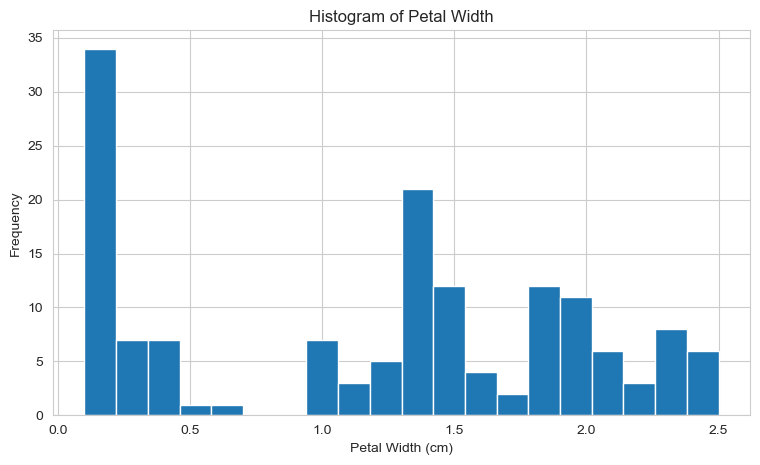

In [7]:
data['petal width'].hist(bins=20)
plt.title('Histogram of Petal Width')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.show()

Multiple peaks suggest the variable may be a mixture of several populations
(here, three species). This is an important warning about distributional shape.

### 4.2 Boxplot

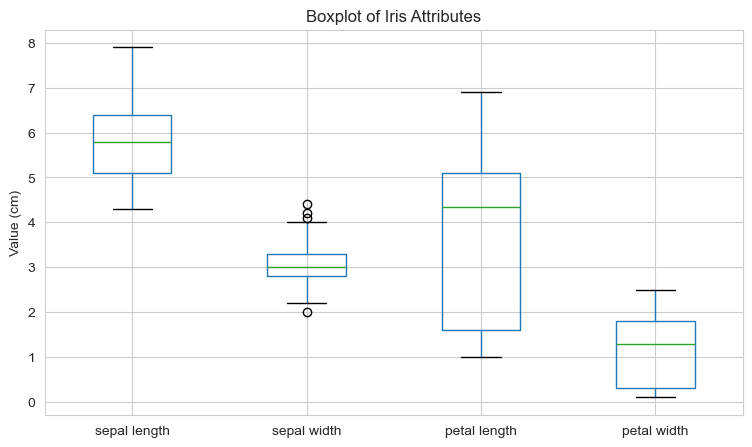

In [8]:
data.boxplot()
plt.title('Boxplot of Iris Attributes')
plt.ylabel('Value (cm)')
plt.show()

Petal length and width have larger ranges than sepal width. No obvious extreme
outliers — we will see what happens when we detect outliers with IQR and Z-score.

### 4.3 Scatter Plot

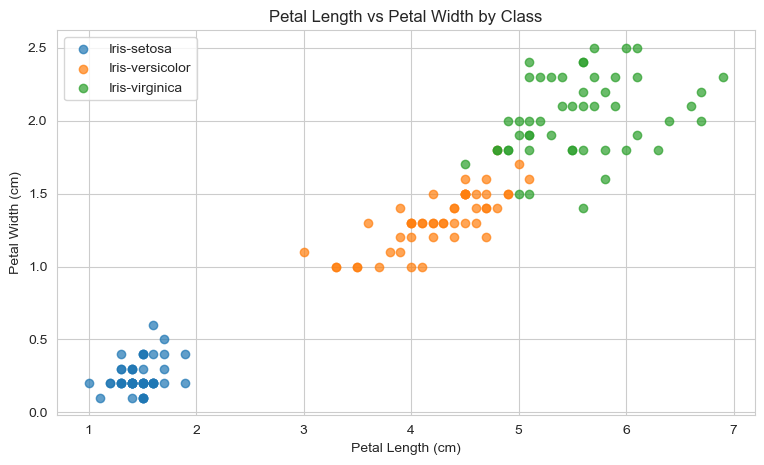

In [9]:
for name, group in data.groupby('class'):
    plt.scatter(group['petal length'], group['petal width'],
                alpha=0.7, label=name)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width by Class')
plt.legend()
plt.show()

Clear separation between species. This tells us the relationship between two
variables can be **strong** and **nonlinear** when a categorical variable is present.

### 4.4 Parallel Coordinates

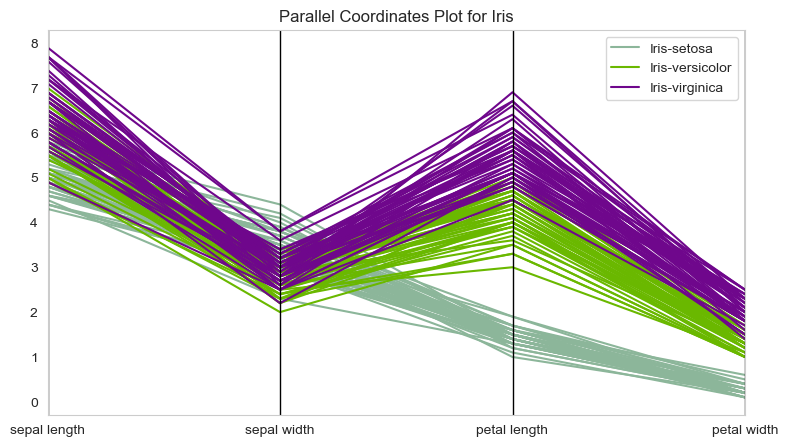

In [10]:
from pandas.plotting import parallel_coordinates
parallel_coordinates(data, 'class')
plt.title('Parallel Coordinates Plot for Iris')
plt.show()

Lines for each species group together, especially for petal length and width.

## 5. Missing Values: Mean vs Median vs KNN Imputation

Switch to a more realistic dataset: `Airbnb.csv`.  
It contains missing values in `review_scores_rating` and `bedrooms`.

We compare three imputation methods and justify the preferred one.  
This is exactly what the assignment requires.

In [11]:
air = pd.read_csv('Airbnb.csv')
air.head()

,id,log_price,property_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_has_profile_pic,host_identity_verified,number_of_reviews,review_scores_rating,bedrooms,beds
0,6901257,5.010635,Apartment,3,1.0,Real Bed,strict,True,NYC,t,t,2,100.0,1,1
1,6304928,5.129899,Apartment,7,1.0,Real Bed,strict,True,NYC,t,f,6,93.0,3,3
2,7919400,4.976734,Apartment,5,1.0,Real Bed,moderate,True,NYC,t,t,10,92.0,1,3
3,13418779,6.620073,House,4,1.0,Real Bed,flexible,True,SF,t,t,0,NaN,2,2
4,3808709,4.744932,Apartment,2,1.0,Real Bed,moderate,True,DC,t,t,4,40.0,0,1


In [12]:
missing = air.isna().sum()
missing_ratio = (missing / len(air)).round(4)
pd.DataFrame({'missing': missing, 'ratio': missing_ratio})[missing > 0]

,missing,ratio
host_has_profile_pic,180,0.0026
host_identity_verified,180,0.0026
review_scores_rating,15275,0.2242


In [13]:
cols = ['review_scores_rating', 'bedrooms']

# Mean
imp_mean = SimpleImputer(strategy='mean')
air[['review_scores_rating_mean', 'bedrooms_mean']] = imp_mean.fit_transform(air[cols])

# Median
imp_med = SimpleImputer(strategy='median')
air[['review_scores_rating_median', 'bedrooms_median']] = imp_med.fit_transform(air[cols])

# KNN
imp_knn = KNNImputer(n_neighbors=5)
knn_vals = imp_knn.fit_transform(air[cols])
air['review_scores_rating_knn'] = knn_vals[:, 0]
air['bedrooms_knn'] = knn_vals[:, 1]

def summary(col):
    s = air[col]
    return pd.Series({'mean': s.mean(), 'std': s.std(),
                      'min': s.min(), 'max': s.max(), 'skew': s.skew()})

pd.DataFrame({
    'review_mean': summary('review_scores_rating_mean'),
    'review_median': summary('review_scores_rating_median'),
    'review_knn': summary('review_scores_rating_knn'),
    'bed_mean': summary('bedrooms_mean'),
    'bed_median': summary('bedrooms_median'),
    'bed_knn': summary('bedrooms_knn'),
}).T

,mean,std,min,max,skew
review_mean,94.012789,6.898510,20.0,100.0,-3.777841
review_median,94.458309,6.948115,20.0,100.0,-3.884890
review_knn,94.380791,6.958347,20.0,100.0,-3.834034
bed_mean,1.271733,0.855334,0.0,10.0,2.005283
bed_median,1.271733,0.855334,0.0,10.0,2.005283
bed_knn,1.271733,0.855334,0.0,10.0,2.005283


**Interpretation**
- `review_scores_rating` is left-skewed (values pile up near 100). Median
  imputation preserves this shape better than mean imputation.
- `bedrooms` is right-skewed. KNN preserves the local structure, median is robust
  to outliers, mean is most sensitive.
- **Preferred choice:** median for both — simple and robust. KNN is a valid
  alternative if local similarity matters.

We build `air_clean` with the preferred method.

In [14]:
air_clean = air.copy()
air_clean['review_scores_rating'] = air_clean['review_scores_rating_median']
air_clean['bedrooms'] = air_clean['bedrooms_median']
air_clean[cols].isna().sum()

review_scores_rating    0
bedrooms                0
dtype: int64

## 6. Outlier Detection: IQR vs Z-score

We apply two standard methods and compare their results.

In [15]:
def iqr_flag(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

def z_flag(s, threshold=3):
    z = (s - s.mean()) / s.std()
    return z.abs() > threshold

for col in ['log_price', 'accommodates', 'bathrooms']:
    n_iqr = iqr_flag(air_clean[col]).sum()
    n_z = z_flag(air_clean[col]).sum()
    print(f"{col}: IQR -> {n_iqr}, Z-score -> {n_z}")

log_price: IQR -> 1453, Z-score -> 453
accommodates: IQR -> 3299, Z-score -> 1378
bathrooms: IQR -> 14307, Z-score -> 1878


In [16]:
air_clean['outlier_iqr'] = iqr_flag(air_clean['log_price'])
air_clean['outlier_iqr'].mean().round(4)

np.float64(0.0213)

**Insight:** IQR usually flags more points because it does not assume a normal
distribution. Z-score assumes an approximately Gaussian variable, so it can
miss heavy-tail outliers and over-flag variables that are not normal.

## 7. Standardization: StandardScaler vs RobustScaler

Different attributes have different scales.

- `StandardScaler`: subtract mean, divide by std. Sensitive to outliers.
- `RobustScaler`: subtract median, divide by IQR. Robust to outliers.

In [17]:
feats = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating']
X = air_clean[feats].copy()

X_std = pd.DataFrame(StandardScaler().fit_transform(X), columns=[f + '_std' for f in feats])
X_rob = pd.DataFrame(RobustScaler().fit_transform(X), columns=[f + '_rob' for f in feats])

print("StandardScaler:")
print(X_std.describe().T[['mean', 'std', 'min', 'max']])
print()
print("RobustScaler:")
print(X_rob.describe().T[['mean', 'std', 'min', 'max']])

StandardScaler:
                                  mean       std        min        max
accommodates_std          3.477992e-17  1.000007  -1.004790   6.021728
bathrooms_std             7.612995e-18  1.000007  -2.185948  12.029751
bedrooms_std             -6.924697e-17  1.000007  -1.486837  10.204586
beds_std                 -8.895733e-17  1.000007  -1.381144  13.212629
review_scores_rating_std -9.453150e-16  1.000007 -10.716411   0.797588

RobustScaler:
                              mean       std        min        max
accommodates_rob          0.572498  1.067393  -0.500000   7.000000
bathrooms_rob             0.230160  0.562762  -1.000000   7.000000
bedrooms_rob              0.271733  0.855334  -1.000000   9.000000
beds_rob                  0.703506  1.233412  -1.000000  17.000000
review_scores_rating_rob -0.256948  1.158019 -12.666667   0.666667


**When to use which:**
- Use `StandardScaler` when features are roughly symmetric and outliers are rare.
- Use `RobustScaler` when features have outliers or skewed distributions.

## 8. Covariance, Correlation, and Correlation ≠ Causation

**Covariance** measures joint variation but depends on scale.  
**Correlation** is scale-free, in [-1, +1], and measures only **linear** association.

In [18]:
corr_cols = ['log_price', 'accommodates', 'bathrooms', 'bedrooms',
             'beds', 'number_of_reviews', 'review_scores_rating']

cov_matrix = air_clean[corr_cols].cov()
corr_matrix = air_clean[corr_cols].corr()

print("Correlation matrix:")
corr_matrix.round(3)

Correlation matrix:


,log_price,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating
log_price,1.000,0.578,0.377,0.483,0.470,-0.025,0.081
accommodates,0.578,1.000,0.523,0.724,0.829,0.052,-0.023
bathrooms,0.377,0.523,1.000,0.609,0.538,-0.040,0.015
bedrooms,0.483,0.724,0.609,1.000,0.730,-0.032,0.012
beds,0.470,0.829,0.538,0.730,1.000,0.038,-0.026
number_of_reviews,-0.025,0.052,-0.040,-0.032,0.038,1.000,-0.026
review_scores_rating,0.081,-0.023,0.015,0.012,-0.026,-0.026,1.000


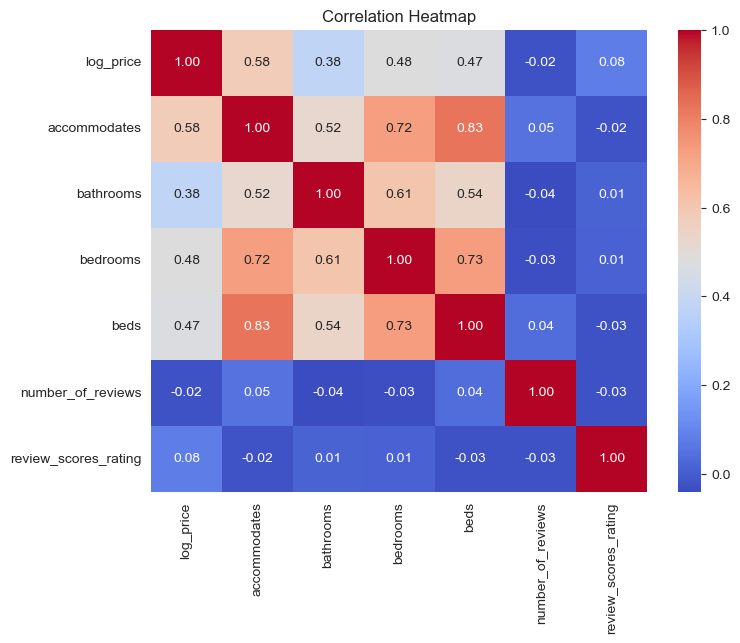

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
air_clean[corr_cols].corr()['log_price'].drop('log_price').sort_values(key=abs, ascending=False).head(5)

accommodates            0.578068
bedrooms                0.482682
beds                    0.469700
bathrooms               0.376758
review_scores_rating    0.080912
Name: log_price, dtype: float64

**Correlation ≠ Causation.**
A larger `accommodates` is strongly correlated with a higher `log_price`, but
size does not *cause* price by itself. Location, amenities, and demand are
confounding factors that affect both.

This is exactly the kind of reasoning required in the assignment.

## 9. Wrap-up

You now have all the tools needed for the Week 3 assignment:
- Descriptive statistics and grouped statistics
- Percentiles, skewness, kurtosis
- Visualization (histogram, boxplot, scatter, parallel coordinates)
- Missing values: mean vs median vs KNN
- Outliers: IQR vs Z-score
- Standardization: StandardScaler vs RobustScaler
- Covariance, correlation, and correlation ≠ causation

# IS6400 Week 3 Assignment

**Total: 100 points**  
**Submit:** `.ipynb` and exported `.html`.  
**Data:** `Airbnb.csv` for Q1 and Q2. Your own project dataset for Q3.

You may use `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`.

All code must be reproducible. Set random seeds where needed.

## Question 1 – Descriptive Analytics on Airbnb (35 points)

Produce a complete descriptive report of `Airbnb.csv`. Your report must include:

- **Attribute type table** for every column: nominal / ordinal / interval / ratio; discrete / continuous; symmetric or asymmetric binary. Include one short reason per column.
- **Full descriptive statistics** for every numerical variable: mean, median, mode, std, min, max, Q1, Q3, IQR, skewness, kurtosis.
- **Frequency and percentage tables** for every categorical variable.
- **Percentile analysis** on both `log_price` and `price = exp(log_price)`: report the 25th, 50th, 75th, 90th, 95th and 99th percentiles. Explain why the percentiles of `price` are **not** simply `exp()` of the percentiles of `log_price`.
- **Group comparison:** for each `city` and each `property_type`, report mean, median, std and IQR of `log_price`. Identify which city and which property type show the highest median price and the highest variability.
- **At least 5 insights**, each citing a specific number from your tables.

**Presentation:** structure your answer as a short analytical report (markdown cells + code + tables), not as a list of tiny tasks.

## Question 2 – Data Quality, Visualization, and Relationships with `log_price` (45 points)

Perform a full exploration of the relationship between features and the target `log_price`, together with data quality handling.

Your answer must include:

**2.1 Data quality**
- Missing-value report for all columns.
- Comparison of **mean**, **median**, and **KNN (k=5)** imputation for `review_scores_rating` and `bedrooms`. Report mean, std, and skewness for each method, and justify your preferred choice.
- Outlier detection on `log_price`, `accommodates`, and `bathrooms` using **both IQR (1.5 × IQR)** and **Z-score (threshold 3)**. Compare the two methods.
- Build `air_clean` using your preferred imputation and keep an `outlier_iqr` flag column.

**2.2 Standardization**
- Apply `StandardScaler` and `RobustScaler` to at least five numerical features (excluding `log_price`).
- Report mean, std, min, max for both scalers. Explain when each scaler is preferable.

**2.3 Feature–target relationships**
- For each of the following features, describe its relationship with `log_price` using **one statistic and one plot**: `property_type`, `accommodates`, `bathrooms`, `review_scores_rating`, `bedrooms`, `beds`.
- Each plot must have a title, axis labels, and 2–3 sentences of interpretation.

**2.4 Correlation and causation**
- Compute the correlation matrix for `log_price` plus all numerical features you used above.
- Plot a heatmap with annotated values.
- Identify the top 3 features most correlated with `log_price`.
- Pick one of them and explain why the correlation does **not** imply causation. Provide a concrete confounding variable.

**Presentation:** at least **8 plots** in total; each with title, labels, and interpretation.  
The narrative should read as a coherent exploration, not as disjoint answers.

## Question 3 – Project Dataset Exploration (20 points)

Import the dataset you may use for your course project.

Deliver a short structured report containing:
- Shape, dtypes, missing values.
- Attribute type table: for every column, nominal / ordinal / interval / ratio and discrete / continuous.
- Choose **at most three** variables and explore their relationships with summary statistics and plots.
- Write a 150–200 word paragraph explaining what you learned and how it could inform later modeling.

**Note:** Different group members must use different variables if working in a group.

## Submission Checklist

- `ipynb` file with all cells executed.
- Exported `HTML` file.
- All plots have titles, axis labels, and interpretations.
- All code is reproducible.
- The submission is well-structured and easy to follow.